# Europe trades power in 15-minute slices now

Since October 2025 the day-ahead auction (SDAC) clears **quarter-hour**
products — most free sites still show hourly averages. The `.qh` series
expose the real auction resolution.

*Data: ENTSO-E Transparency Platform; Fraunhofer Energy-Charts CC BY 4.0; GIE — via [obsyd.dev](https://obsyd.dev) (free, AGPL-3.0). Descriptive, not a forecast.*

In [1]:
# pip install obsyd matplotlib
import datetime as dt
import matplotlib.pyplot as plt
from obsyd import Obsyd

ob = Obsyd()
# Ranges end YESTERDAY (UTC) — today's late hours may not be published yet.
END = dt.date.today() - dt.timedelta(days=1)
START = END - dt.timedelta(days=7)
ZONE = 'DE_LU'

In [2]:
hourly = ob.series('price.dayahead', ZONE, start=START, end=END)
qh = ob.series('price.dayahead.qh', ZONE, start=START, end=END)
len(hourly), len(qh)

(168, 671)

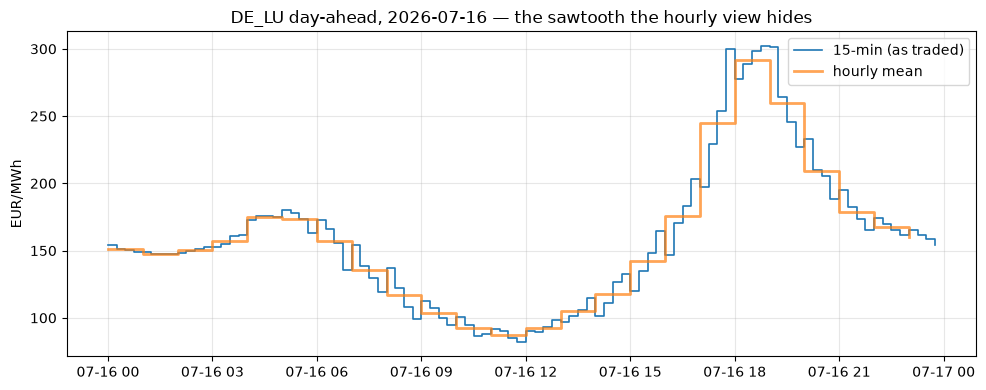

In [3]:
day = END - dt.timedelta(days=1)
h1 = hourly.loc[str(day)]
q1 = qh.loc[str(day)]
fig, ax = plt.subplots(figsize=(10, 4))
ax.step(q1.index, q1['value'], where='post', label='15-min (as traded)', lw=1.2)
ax.step(h1.index, h1['value'], where='post', label='hourly mean', lw=2, alpha=0.7)
ax.set_title(f'{ZONE} day-ahead, {day} — the sawtooth the hourly view hides')
ax.set_ylabel('EUR/MWh'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()

In [4]:
# How much structure does the hourly average smooth away?
swing = qh['value'].resample('1h').agg(lambda s: s.max() - s.min())
print(f'mean intra-hour swing: {swing.mean():.1f} EUR/MWh')
print(f'max intra-hour swing:  {swing.max():.1f} EUR/MWh')

mean intra-hour swing: 21.9 EUR/MWh
max intra-hour swing:  102.6 EUR/MWh
